2024-11-27 11:20:24,443 - __main__ - INFO - Loaded configuration from config.json
2024-11-27 11:20:24,445 - __main__ - INFO - Loading data...
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
2024-11-27 11:20:25,304 - __main__ - INFO - Training model...
2024-11-27 11:20:25,305 - __main__ - INFO - Training on device: cpu
2024-11-27 11:20:42,256 - __main__ - INFO - Epoch 10, G Loss: 0.1311, D Loss: 0.6963
2024-11-27 11:20:42,278 - __main__ - INFO - Privacy metrics at epoch 10:
2024-11-27 11:20:42,278 - __main__ - INFO -   Membership Inference Risk: 1.0000
2024-11-27 11:20:42,279 - __main__ - INFO -   Model Inversion Risk: 0.3028
2024-11-27 11:20:42,280 - __main__ - INFO -   Reconstruction Risk: 0.0106
2024-11-27 11:20:42,281 - __main__ - INFO -   Privacy Score: 0.5622
2024-11-27 11:20:42,281 - __main__ - INFO -   DP Strength: Weak
2024-11-27 11:20:58,429 - __main__ - INFO - Epoch 20, G Loss: 0.1417, D

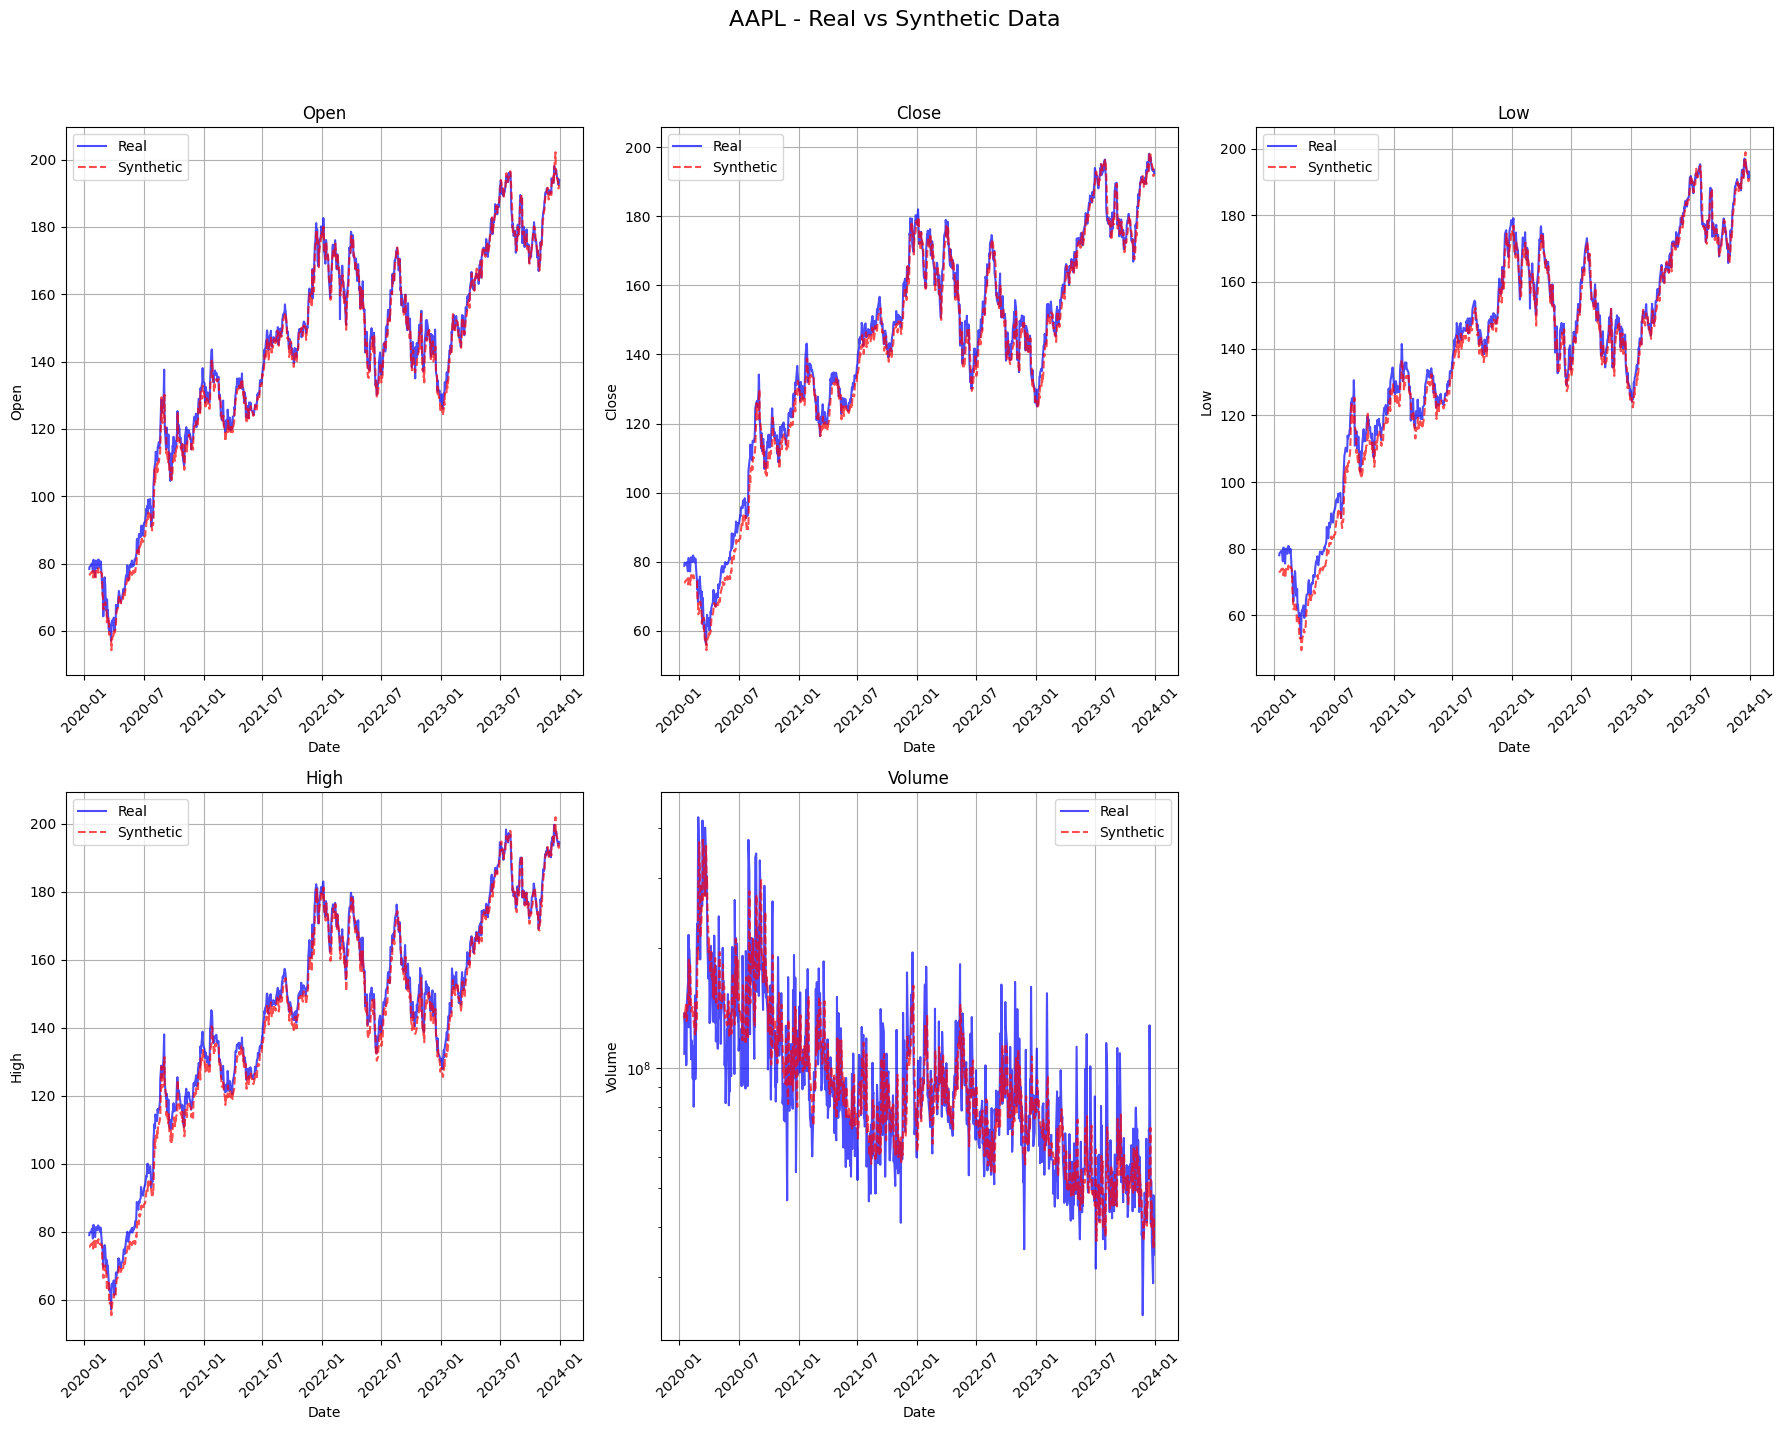

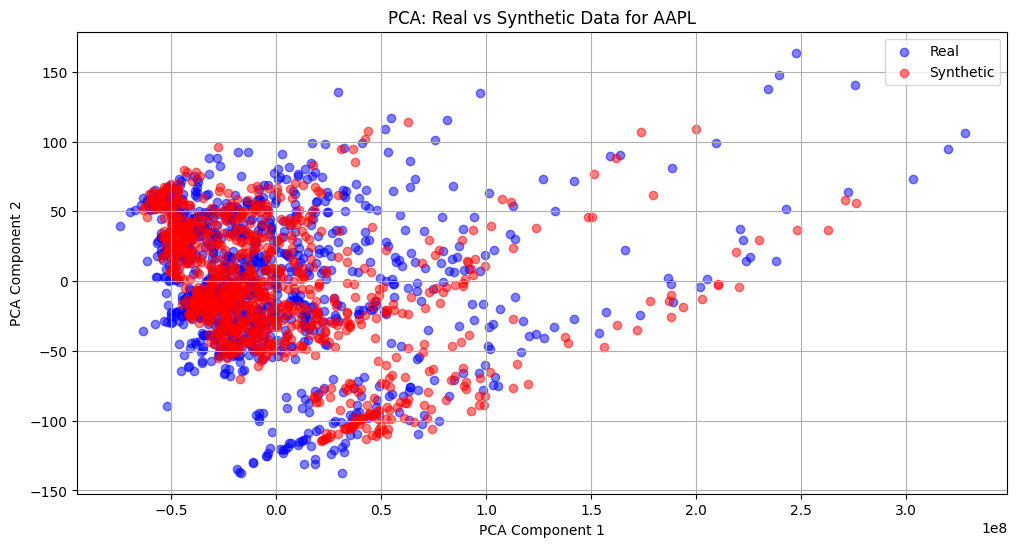

/Users/lucijagregov/Documents/gan_finance/.fin_gan/lib/python3.11/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


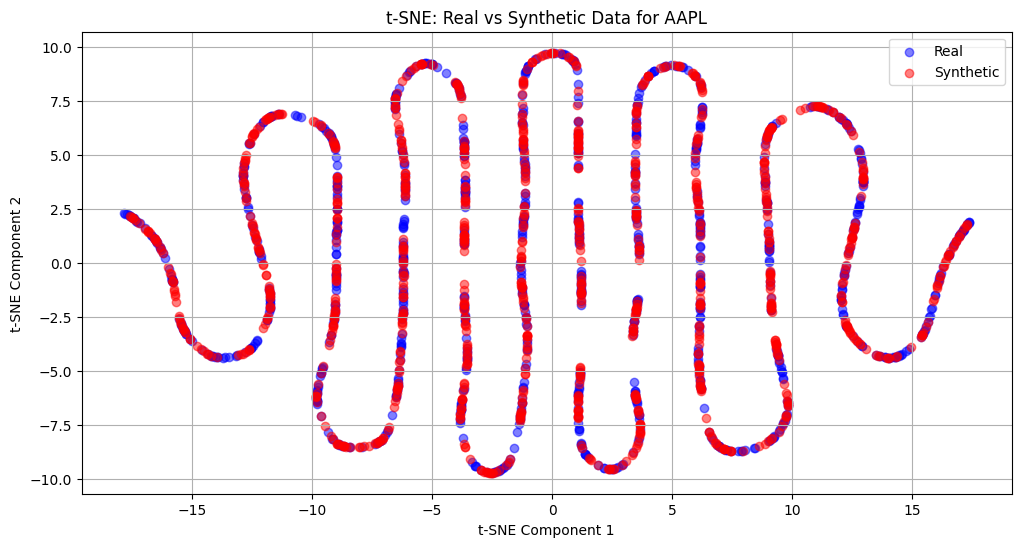

2024-11-27 11:23:26,924 - __main__ - INFO - Processing MSFT...
2024-11-27 11:23:27,294 - __main__ - INFO - 
Evaluation Metrics for MSFT:
2024-11-27 11:23:27,299 - __main__ - INFO - Feature: open
2024-11-27 11:23:27,300 - __main__ - INFO -   MSE: 13.4811
2024-11-27 11:23:27,301 - __main__ - INFO -   Pearson Correlation: 0.9979
2024-11-27 11:23:27,302 - __main__ - INFO -   Wasserstein Distance: 1.6255

2024-11-27 11:23:27,307 - __main__ - INFO - Feature: close
2024-11-27 11:23:27,307 - __main__ - INFO -   MSE: 26.8032
2024-11-27 11:23:27,308 - __main__ - INFO -   Pearson Correlation: 0.9956
2024-11-27 11:23:27,309 - __main__ - INFO -   Wasserstein Distance: 1.5106

2024-11-27 11:23:27,316 - __main__ - INFO - Feature: low
2024-11-27 11:23:27,317 - __main__ - INFO -   MSE: 18.8491
2024-11-27 11:23:27,317 - __main__ - INFO -   Pearson Correlation: 0.9971
2024-11-27 11:23:27,318 - __main__ - INFO -   Wasserstein Distance: 1.7836

2024-11-27 11:23:27,323 - __main__ - INFO - Feature: high
2024

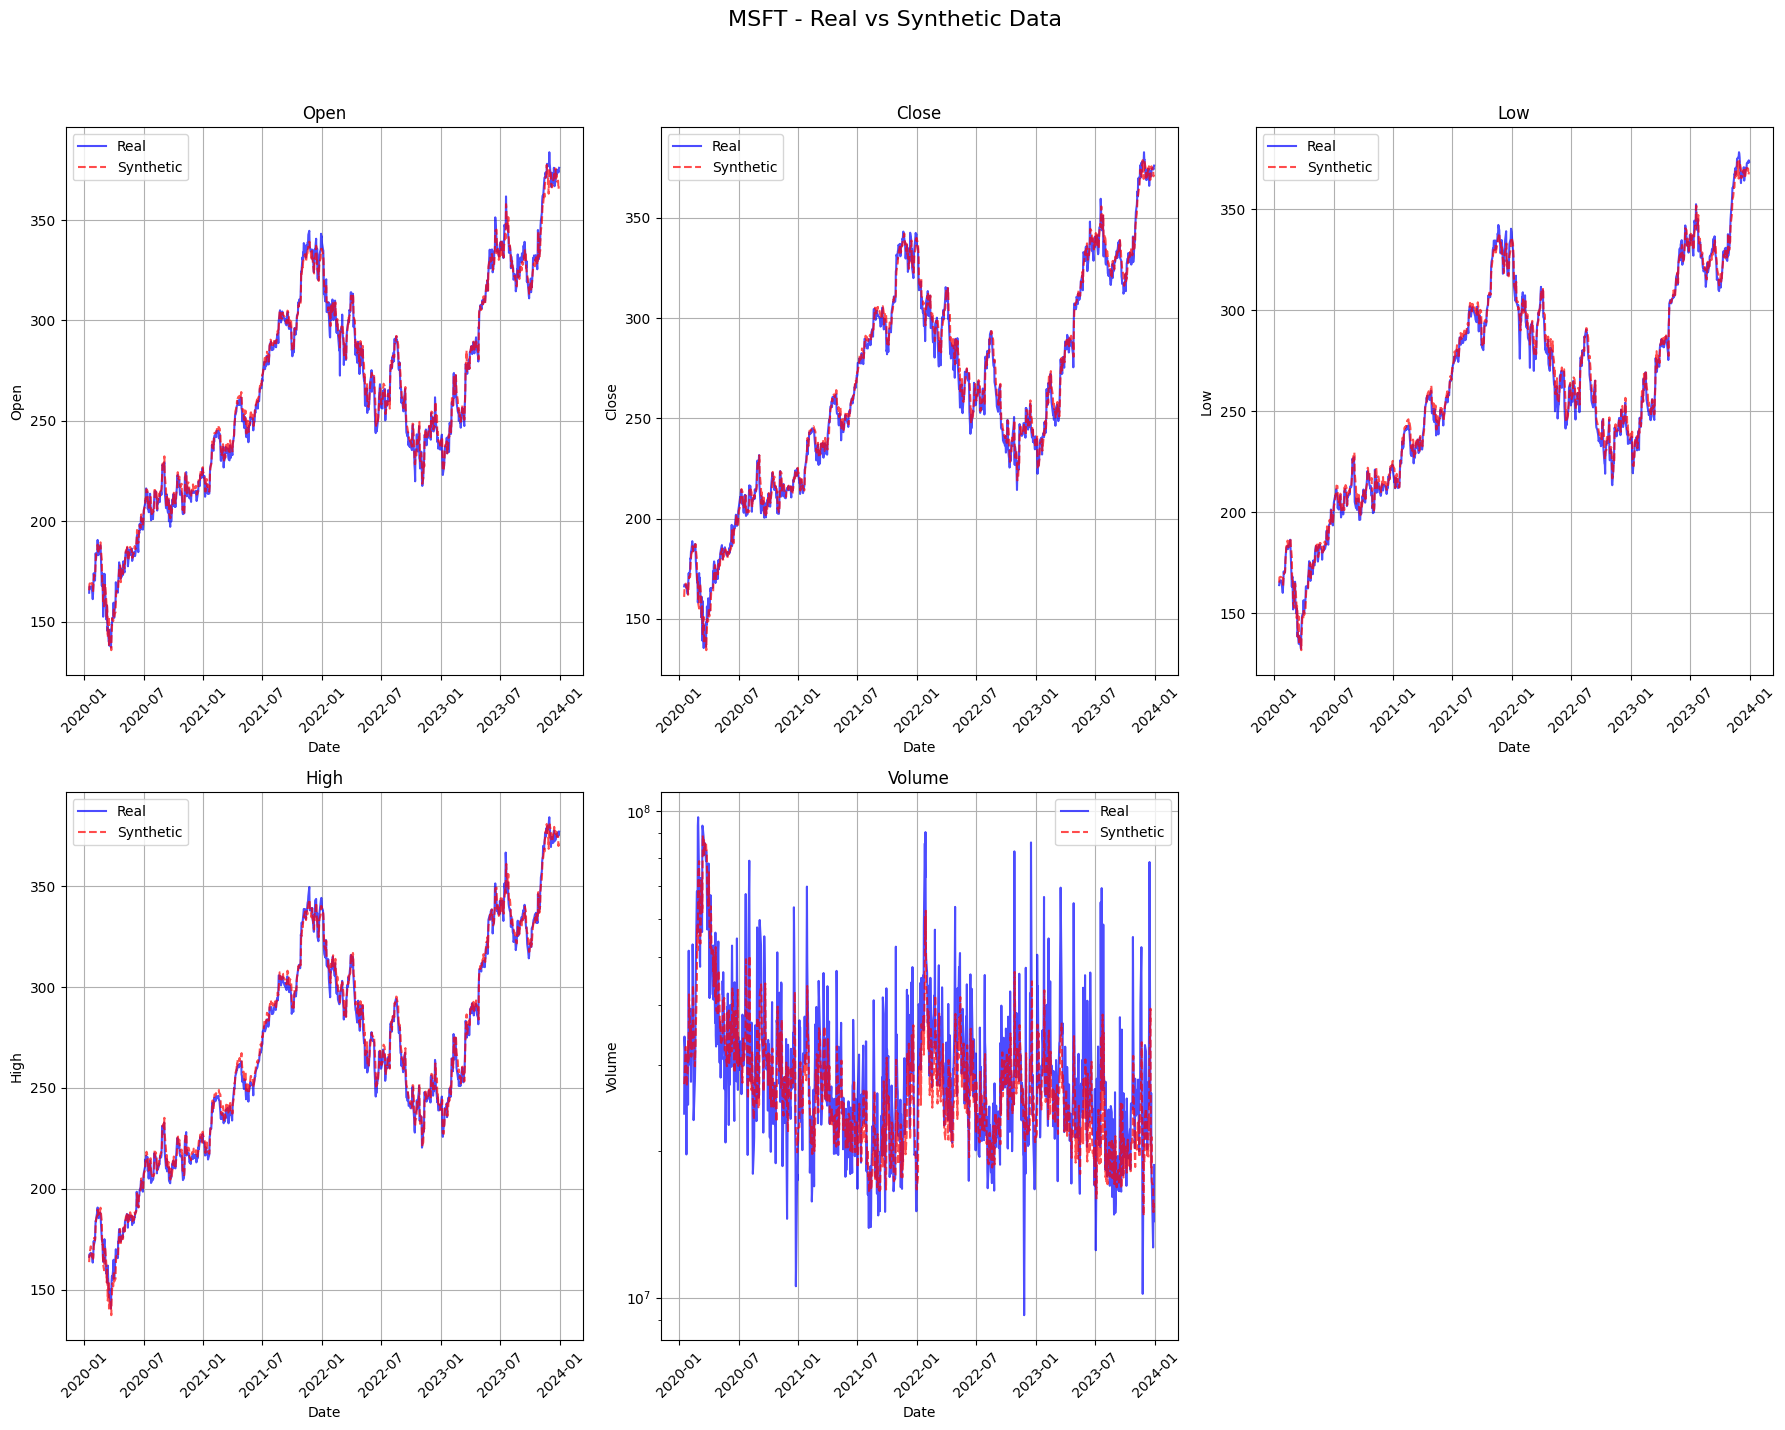

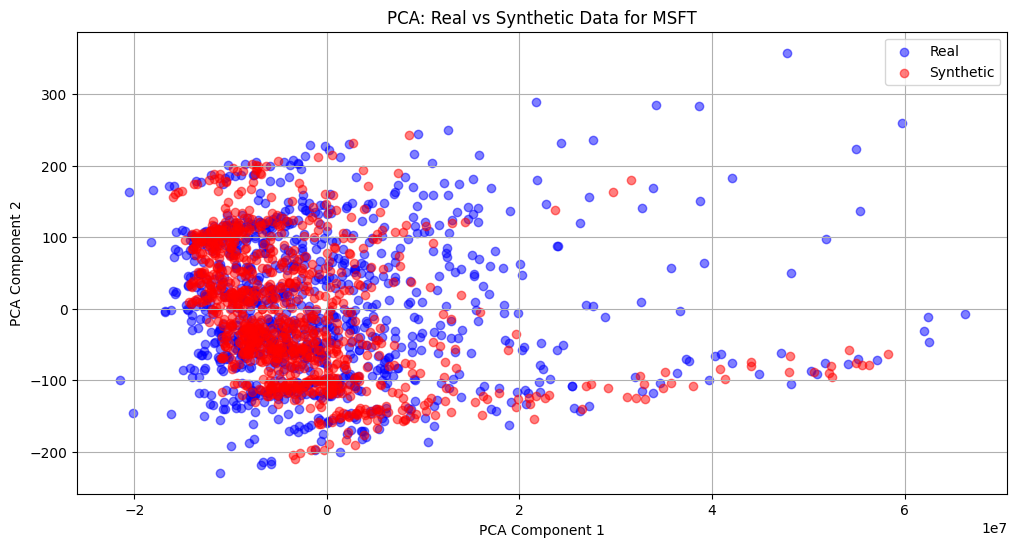

/Users/lucijagregov/Documents/gan_finance/.fin_gan/lib/python3.11/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


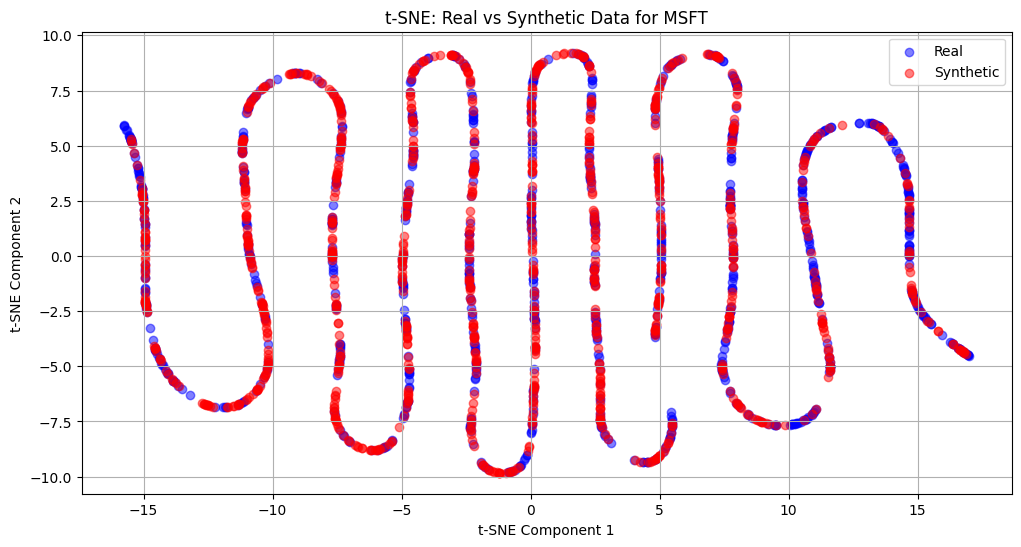

2024-11-27 11:23:38,268 - __main__ - INFO - Processing completed successfully


In [ ]:
"""
Financial Time Series Generation using GAN with Differential Privacy.

This module implements a GAN-based approach for generating synthetic financial time series data
with differential privacy guarantees. It uses a Transformer-based generator and an enhanced
discriminator with proper gradient clipping and noise addition for privacy preservation.
"""

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.metrics import mean_squared_error
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.stats import wasserstein_distance, pearsonr
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from datetime import datetime
import random
from pathlib import Path
import logging
from typing import Tuple, List, Dict, Optional, Union, Iterator, Any, TypeVar, Callable
import json
from torch.nn.parallel import DistributedDataParallel as DDP
import torch.distributed as dist
import os
from opendp.mod import enable_features


# Type variables
T = TypeVar('T')
ModelType = TypeVar('ModelType', bound=nn.Module)
DataType = TypeVar('DataType', pd.DataFrame, np.ndarray, torch.Tensor)

# Setup logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)


def set_seeds(seed: int = 42) -> None:
    """
    Set random seeds for reproducibility.
    
    Args:
        seed: Integer seed for random number generators
        
    Note:
        Sets seeds for Python's random, NumPy, and PyTorch (CPU and CUDA)
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

def setup_distributed() -> Tuple[torch.device, int]:
    """
    Setup distributed training environment.
    
    Returns:
        Tuple containing:
            - PyTorch device (cuda or cpu)
            - Rank of the current process
            
    Note:
        Initializes distributed training if environment variables are set
    """
    if torch.cuda.is_available():
        if 'RANK' in os.environ and 'WORLD_SIZE' in os.environ:
            rank = int(os.environ['RANK'])
            world_size = int(os.environ['WORLD_SIZE'])
            dist.init_process_group(backend='nccl', rank=rank, world_size=world_size)
            device = torch.device(f'cuda:{rank}')
            return device, rank
        else:
            return torch.device('cuda'), 0
    return torch.device('cpu'), 0

def setup_environment(
    config: Dict[str, Any],
    checkpoint_dir: str,
    output_dir: str
) -> None:
    """
    Setup training environment.
    
    Args:
        config: Configuration dictionary
        checkpoint_dir: Directory for checkpoints
        output_dir: Directory for outputs
        
    Raises:
        RuntimeError: If environment setup fails
    """
    try:
        # Set random seeds
        set_seeds(config["seed"])
        
        # Create directories
        for directory in [checkpoint_dir, output_dir]:
            Path(directory).mkdir(parents=True, exist_ok=True)
            
    except Exception as e:
        logger.error(f"Error setting up environment: {str(e)}")
        raise RuntimeError(f"Environment setup failed: {str(e)}")

def clip_gradients(parameters: Iterator[nn.Parameter], max_grad_norm: float) -> None:
    """
    Clip gradients by global norm for stable training.
    
    Args:
        parameters: Iterator of model parameters
        max_grad_norm: Maximum allowed norm of the gradients
        
    Returns:
        None
        
    Note:
        Modifies gradients in-place to ensure their global norm does not exceed max_grad_norm
    """
    if isinstance(parameters, torch.Tensor):
        parameters = [parameters]
    
    total_norm: float = 0.0
    for param in parameters:
        if param.requires_grad and param.grad is not None:
            param_norm = param.grad.data.norm(2)
            total_norm += param_norm.item() ** 2
    total_norm = total_norm ** 0.5

    clip_coef = max_grad_norm / (total_norm + 1e-6)
    if clip_coef < 1:
        for param in parameters:
            if param.requires_grad and param.grad is not None:
                param.grad.data.mul_(clip_coef)

def add_noise_to_gradients(parameters: Iterator[nn.Parameter], noise_scale: float) -> None:
    """
    Add Gaussian noise to gradients for differential privacy.
    
    Args:
        parameters: Iterator of model parameters
        noise_scale: Standard deviation of the Gaussian noise
        
    Returns:
        None
        
    Note:
        Modifies gradients in-place by adding random noise for privacy preservation
    """
    if isinstance(parameters, torch.Tensor):
        parameters = [parameters]
    
    for param in parameters:
        if param.requires_grad and param.grad is not None:
            noise = torch.normal(
                mean=0.0,
                std=noise_scale,
                size=param.grad.shape,
                device=param.grad.device
            )
            param.grad.data.add_(noise)

class CombinedScaler:
    """
    Custom scaler that handles dates, prices, and volume separately with appropriate scaling.
    
    Attributes:
        date_scaler: MinMaxScaler for date ordinals
        price_scaler: RobustScaler for price features
        volume_scaler: RobustScaler for volume features
        price_features: List of price-related feature names
        volume_features: List of volume-related feature names
    """
    
    def __init__(
        self, 
        date_scaler: MinMaxScaler, 
        price_scaler: RobustScaler, 
        volume_scaler: RobustScaler
    ) -> None:
        """
        Initialize the combined scaler.
        
        Args:
            date_scaler: Scaler for dates
            price_scaler: Scaler for price features
            volume_scaler: Scaler for volume features
        """
        self.date_scaler = date_scaler
        self.price_scaler = price_scaler
        self.volume_scaler = volume_scaler
        self.price_features: List[str] = ['open', 'close', 'low', 'high']
        self.volume_features: List[str] = ['volume']
    
    def transform(self, X: pd.DataFrame) -> np.ndarray:
        """
        Transform the input data using appropriate scaling for each feature type.
        
        Args:
            X: Input DataFrame containing dates, prices, and volume
            
        Returns:
            Transformed array with scaled features
            
        Note:
            Applies log1p transformation to volume before scaling
        """
        dates = self.date_scaler.transform(X[['date_ordinal']])
        prices = self.price_scaler.transform(X[self.price_features])
        volume = self.volume_scaler.transform(np.log1p(X[self.volume_features]))
        return np.hstack([dates, prices, volume])
    
    def inverse_transform(self, X: np.ndarray) -> np.ndarray:
        """
        Inverse transform the scaled data back to original scale.
        
        Args:
            X: Array of transformed values
            
        Returns:
            Array with original-scale features
            
        Note:
            Applies expm1 transformation to volume after inverse scaling
        """
        n_date_features = 1
        n_price_features = len(self.price_features)
        n_volume_features = len(self.volume_features)
        
        dates = X[:, :n_date_features]
        prices = X[:, n_date_features:n_date_features + n_price_features]
        volume = X[:, -n_volume_features:]
        
        dates = self.date_scaler.inverse_transform(dates)
        prices = self.price_scaler.inverse_transform(prices)
        volume = np.expm1(self.volume_scaler.inverse_transform(volume))
        
        return np.hstack([dates, prices, volume])

class TransformerGenerator(nn.Module):
    """
    Transformer-based generator model for synthetic data generation.
    
    Attributes:
        input_size: Dimension of input features
        positional_encoding: Linear layer for encoding input features
        transformer_encoder: TransformerEncoder for sequence processing
        decoder: Linear layer for output generation
    """
    
    def __init__(
        self, 
        input_size: int,
        num_layers: int,
        d_model: int,
        nhead: int,
        dim_feedforward: int,
        output_size: int,
        dropout: float = 0.1
    ) -> None:
        """
        Initialize the generator.
        
        Args:
            input_size: Number of input features
            num_layers: Number of transformer layers
            d_model: Dimension of the model
            nhead: Number of heads in multi-head attention
            dim_feedforward: Dimension of feedforward network
            output_size: Number of output features
            dropout: Dropout rate
        """
        super(TransformerGenerator, self).__init__()
        self.input_size = input_size
        self.positional_encoding = nn.Linear(input_size, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.decoder = nn.Linear(d_model, output_size)
        
    def forward(self, src: torch.Tensor) -> torch.Tensor:
        """
        Forward pass of the generator.
        
        Args:
            src: Input tensor of shape (batch_size, sequence_length, input_size)
            
        Returns:
            Output tensor of shape (batch_size, output_size)
        """
        src = self.positional_encoding(src)
        output = self.transformer_encoder(src)
        output = self.decoder(output[:, -1, :])
        return output
    
class EnhancedDiscriminator(nn.Module):
    """
    Enhanced discriminator with dropout and batch normalization.
    
    Attributes:
        model: Sequential model containing linear layers with batch norm and dropout
    """
    
    def __init__(
        self, 
        input_size: int, 
        hidden_sizes: List[int] = [128, 64, 32]
    ) -> None:
        """
        Initialize the discriminator.
        
        Args:
            input_size: Number of input features
            hidden_sizes: List of hidden layer sizes
        """
        super(EnhancedDiscriminator, self).__init__()
        layers = []
        current_size = input_size
        
        for hidden_size in hidden_sizes:
            layers.extend([
                nn.Linear(current_size, hidden_size),
                nn.BatchNorm1d(hidden_size),
                nn.LeakyReLU(0.2),
                nn.Dropout(0.3)
            ])
            current_size = hidden_size
        
        layers.extend([
            nn.Linear(hidden_sizes[-1], 1),
            nn.Sigmoid()
        ])
        
        self.model = nn.Sequential(*layers)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass of the discriminator.
        
        Args:
            x: Input tensor
            
        Returns:
            Probability of input being real
        """
        return self.model(x)

class EarlyStopping:
    """
    Early stopping handler to prevent overfitting.
    
    Attributes:
        patience: Number of epochs to wait before stopping
        min_delta: Minimum change in monitored value
        counter: Number of epochs with no improvement
        best_loss: Best loss achieved
        early_stop: Whether to stop training
    """
    
    def __init__(self, patience: int = 10, min_delta: float = 0.001) -> None:
        """
        Initialize early stopping.
        
        Args:
            patience: Number of epochs to wait
            min_delta: Minimum change in monitored value
        """
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss: Optional[float] = None
        self.early_stop = False
    
    def __call__(self, val_loss: float) -> bool:
        """
        Check if training should stop.
        
        Args:
            val_loss: Current validation loss
            
        Returns:
            Boolean indicating whether to stop training
        """
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0
        return self.early_stop

def setup_distributed() -> Tuple[torch.device, int]:
    """
    Setup distributed training environment.
    
    Returns:
        Tuple of (device, rank)
        
    Note:
        Returns CPU device and rank 0 if CUDA is not available
    """
    if torch.cuda.is_available():
        if 'RANK' in os.environ and 'WORLD_SIZE' in os.environ:
            rank = int(os.environ['RANK'])
            world_size = int(os.environ['WORLD_SIZE'])
            dist.init_process_group(backend='nccl', rank=rank, world_size=world_size)
            device = torch.device(f'cuda:{rank}')
            return device, rank
        else:
            return torch.device('cuda'), 0
    return torch.device('cpu'), 0

def save_checkpoint(
    state: Dict[str, Any],
    is_best: bool,
    checkpoint_dir: str,
    filename: str = 'checkpoint.pth.tar'
) -> None:
    """
    Save model checkpoint.
    
    Args:
        state: State dictionary to save
        is_best: Whether this is the best model so far
        checkpoint_dir: Directory to save checkpoint
        filename: Name of checkpoint file
    """
    filepath = Path(checkpoint_dir) / filename
    torch.save(state, filepath)
    if is_best:
        best_filepath = Path(checkpoint_dir) / 'model_best.pth.tar'
        torch.save(state, best_filepath)

def load_checkpoint(
    checkpoint_path: str,
    generator: ModelType,
    discriminator: ModelType
) -> Dict[str, Any]:
    """
    Load model checkpoint.
    
    Args:
        checkpoint_path: Path to checkpoint file
        generator: Generator model
        discriminator: Discriminator model
        
    Returns:
        Checkpoint state dictionary
        
    Raises:
        FileNotFoundError: If checkpoint file doesn't exist
    """
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(f"No checkpoint found at {checkpoint_path}")
    
    checkpoint = torch.load(checkpoint_path, map_location='cpu')
    generator.load_state_dict(checkpoint['generator_state_dict'])
    discriminator.load_state_dict(checkpoint['discriminator_state_dict'])
    return checkpoint

def get_lr_scheduler(
    optimizer: torch.optim.Optimizer, 
    config: Dict[str, Any]
) -> torch.optim.lr_scheduler.ReduceLROnPlateau:
    """
    Create learning rate scheduler with plateau detection.
    
    Args:
        optimizer: PyTorch optimizer instance
        config: Configuration dictionary containing scheduler parameters
        
    Returns:
        ReduceLROnPlateau scheduler
        
    Note:
        Expects config to contain 'training_params' with:
            - scheduler_patience: Number of epochs to wait before reducing LR
            - scheduler_factor: Factor by which to reduce LR
    """
    return torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        patience=config['training_params']['scheduler_patience'],
        factor=config['training_params']['scheduler_factor'],
        verbose=True
    )

def warmup_learning_rate(
    epoch: int, 
    warmup_epochs: int, 
    base_lr: float
) -> float:
    """
    Calculate learning rate during warmup period.

    Args:
        epoch: Current epoch number
        warmup_epochs: Number of warmup epochs
        base_lr: Base learning rate to reach after warmup
        
    Returns:
        Calculated learning rate for current epoch
        
    Note:
        Learning rate increases linearly from 0 to base_lr during warmup
    """
    if epoch >= warmup_epochs:
        return base_lr
    return base_lr * (epoch + 1) / warmup_epochs

# from typing import Tuple, List, Dict, Any
# import torch
# import torch.nn as nn
# from torch.utils.data import DataLoader, TensorDataset
# from torch.optim import Optimizer
# from datetime import datetime
# import numpy as np
# import logging

# logger = logging.getLogger(__name__)
def train_gan_with_manual_dp(
    data: pd.DataFrame,
    features: List[str],
    sequence_length: int = 10,
    epochs: int = 200,
    batch_size: int = 64,
    noise_scale: float = 0.5,
    max_grad_norm: float = 1.0,
    checkpoint_dir: str = 'checkpoints',
    patience: int = 20,
    config: Dict[str, Any] = None
) -> Tuple[nn.Module, Any, torch.device]:
    """
    Train a GAN with manual differential privacy using gradient clipping and noise addition.
    
    Args:
        data: Input DataFrame with financial time series data.
        features: List of feature names to use in training.
        sequence_length: Length of input sequences for temporal modeling.
        epochs: Maximum number of training epochs.
        batch_size: Size of training batches.
        noise_scale: Scale of noise for differential privacy.
        max_grad_norm: Maximum gradient norm for clipping.
        checkpoint_dir: Directory to save checkpoints.
        patience: Number of epochs to wait before early stopping.
        config: Configuration dictionary with model and training parameters.
    
    Returns:
        Tuple containing:
            - Trained generator model.
            - Combined scaler for data transformation.
            - Device used for training.
    
    Raises:
        RuntimeError: If training fails.
        ValueError: If input data or parameters are invalid.
    """
    if config is None:
        raise ValueError("Configuration dictionary must be provided")
    if len(data) <= sequence_length:
        raise ValueError("Data length must be greater than sequence length")
    
    try:
        # Setup device
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        logger.info(f"Training on device: {device}")
        
        # Initialize scalers (assumes CombinedScaler exists)
        date_scaler = MinMaxScaler()
        price_scaler = RobustScaler()
        volume_scaler = RobustScaler()
        
        # Extract features for scaling
        data['date_ordinal'] = pd.to_datetime(data['date']).map(datetime.toordinal)
        df_dates = data[['date_ordinal']]
        price_features = [f for f in features if f not in ['volume', 'date_ordinal']]
        volume_features = ['volume'] if 'volume' in features else []
        
        df_prices = data[price_features] if price_features else pd.DataFrame()
        df_volume = data[volume_features] if volume_features else pd.DataFrame()
        
        # Fit scalers
        date_scaler.fit(df_dates)
        if not df_prices.empty:
            price_scaler.fit(df_prices)
        if not df_volume.empty:
            volume_scaler.fit(np.log1p(df_volume))  # Apply log1p scaling to volume
        
        combined_scaler = CombinedScaler(date_scaler, price_scaler, volume_scaler)
        
        # Transform data
        scaled_dates = date_scaler.transform(df_dates)
        scaled_prices = price_scaler.transform(df_prices) if not df_prices.empty else np.array([])
        scaled_volume = volume_scaler.transform(np.log1p(df_volume)) if not df_volume.empty else np.array([])
        
        # Combine scaled features
        scaled_features_list = [scaled_dates]
        if not df_prices.empty:
            scaled_features_list.append(scaled_prices)
        if not df_volume.empty:
            scaled_features_list.append(scaled_volume)
        
        scaled_features = np.hstack(scaled_features_list)
        
        # Create sequences for time-series data
        X, y = [], []
        for i in range(len(scaled_features) - sequence_length):
            X.append(scaled_features[i:i+sequence_length])
            y.append(scaled_features[i+sequence_length])
        
        X_array = np.array(X)
        y_array = np.array(y)
        
        X_tensor = torch.tensor(X_array, dtype=torch.float32)
        y_tensor = torch.tensor(y_array, dtype=torch.float32)
        
        dataset = TensorDataset(X_tensor, y_tensor)
        data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
        
        # Initialize models
        generator = TransformerGenerator(
            input_size=X_array.shape[2],
            num_layers=config['model_params']['generator']['num_layers'],
            d_model=config['model_params']['generator']['d_model'],
            nhead=config['model_params']['generator']['nhead'],
            dim_feedforward=config['model_params']['generator']['dim_feedforward'],
            output_size=y_array.shape[1],
            dropout=config['model_params']['generator']['dropout']
        ).to(device)
        
        discriminator = EnhancedDiscriminator(
            input_size=y_array.shape[1],
            hidden_sizes=config['model_params']['discriminator']['hidden_sizes']
        ).to(device)
        
        # Optimizers
        g_optimizer = torch.optim.Adam(generator.parameters(), lr=config['training_params']['g_learning_rate'])
        d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=config['training_params']['d_learning_rate'])
        
        # Loss functions
        adversarial_loss = nn.BCELoss()
        
        # Training loop
        for epoch in range(epochs):
            
            total_g_loss = 0.0
            total_d_loss = 0.0
            
            generator.train()
            discriminator.train()
            
            for batch_X, batch_y in data_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                batch_size = batch_X.size(0)
                
                # Train Discriminator
                d_optimizer.zero_grad()
                
                # Real data
                real_labels = torch.ones(batch_size, 1).to(device)
                fake_labels = torch.zeros(batch_size, 1).to(device)
                
                real_outputs = discriminator(batch_y)
                d_loss_real = adversarial_loss(real_outputs, real_labels)
                
                # Fake data
                fake_data = generator(batch_X)
                fake_outputs = discriminator(fake_data.detach())
                d_loss_fake = adversarial_loss(fake_outputs, fake_labels)
                
                d_loss = (d_loss_real + d_loss_fake) / 2
                d_loss.backward()
                d_optimizer.step()
                
                # Train Generator
                g_optimizer.zero_grad()
                
                fake_data = generator(batch_X)
                fake_outputs = discriminator(fake_data)
                g_loss_adv = adversarial_loss(fake_outputs, real_labels)
                
                # Weighted feature loss (MSE for each feature)
                mse_loss_per_feature = torch.mean((fake_data - batch_y) ** 2, dim=0)
                
                # Dynamically adjust feature weights
                feature_weights = torch.ones_like(mse_loss_per_feature, device=batch_y.device)
                feature_weights[-1] = 2.0  # Example: Assign higher weight to 'volume'
                
                weighted_mse_loss = torch.sum(feature_weights * mse_loss_per_feature)
                
                # Combined generator loss
                adv_weight = config['training_params']['adv_weight']
                g_loss = adv_weight * g_loss_adv + (1 - adv_weight) * weighted_mse_loss
                
                g_loss.backward()
                g_optimizer.step()
                

            if (epoch + 1) % 10 == 0:
                total_g_loss += g_loss.item()
                total_d_loss += d_loss.item()
                logger.info(f"Epoch {epoch+1}, G Loss: {total_g_loss:.4f}, D Loss: {total_d_loss:.4f}")
                privacy_metrics = test_privacy_strength(
                    generator=generator,
                    discriminator=discriminator,
                    real_data=batch_X,
                    noise_scale=config['noise_scale']
                )

                # Log privacy metrics
                logger.info(f"Privacy metrics at epoch {epoch + 1}:")
                logger.info(f"  Membership Inference Risk: {privacy_metrics['membership_inference_risk']:.4f}")
                logger.info(f"  Model Inversion Risk: {privacy_metrics['model_inversion_risk']:.4f}")
                logger.info(f"  Reconstruction Risk: {privacy_metrics['reconstruction_risk']:.4f}")
                logger.info(f"  Privacy Score: {privacy_metrics['privacy_score']:.4f}")
                logger.info(f"  DP Strength: {privacy_metrics['dp_strength']}")
        
        return generator, combined_scaler, device
    
    except Exception as e:
        logger.error(f"Training failed: {e}")
        raise RuntimeError(f"Training failed: {e}")



def evaluate_generated_data(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    features: List[str],
    ticker: str
) -> Dict[str, Dict[str, float]]:
    """
    Evaluate generated data against real data using multiple metrics.
    
    Args:
        y_true: True values array
        y_pred: Predicted values array
        features: List of feature names
        ticker: Ticker symbol
        
    Returns:
        Dictionary containing evaluation metrics for each feature:
            - MSE
            - Pearson correlation
            - Wasserstein distance
            
    Raises:
        ValueError: If input shapes don't match or features are invalid
    """
    if y_true.shape != y_pred.shape:
        raise ValueError(f"Shape mismatch: y_true {y_true.shape} != y_pred {y_pred.shape}")
    if len(features) != y_true.shape[1]:
        raise ValueError(f"Feature count mismatch: {len(features)} != {y_true.shape[1]}")
    
    metrics: Dict[str, Dict[str, float]] = {}
    logger.info(f"\nEvaluation Metrics for {ticker}:")
    
    for i, feature in enumerate(features):
        try:
            mse = mean_squared_error(y_true[:, i], y_pred[:, i])
            corr, _ = pearsonr(y_true[:, i], y_pred[:, i])
            wasserstein = wasserstein_distance(y_true[:, i], y_pred[:, i])
            
            metrics[feature] = {
                'mse': mse,
                'correlation': corr,
                'wasserstein': wasserstein
            }
            
            logger.info(f"Feature: {feature}")
            logger.info(f"  MSE: {mse:.4f}")
            logger.info(f"  Pearson Correlation: {corr:.4f}")
            logger.info(f"  Wasserstein Distance: {wasserstein:.4f}\n")
            
        except Exception as e:
            logger.error(f"Error evaluating feature {feature}: {str(e)}")
            metrics[feature] = {
                'mse': float('nan'),
                'correlation': float('nan'),
                'wasserstein': float('nan')
            }
    
    return metrics

def plot_comparisons_grid(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    dates: pd.Series,
    features: List[str],
    ticker: str,
    save_path: Optional[str] = None,
    figsize: Tuple[int, int] = (18, 15)
) -> None:
    """
    Plot comparisons between real and synthetic data in a grid layout.

    Args:
        y_true: True values array
        y_pred: Predicted values array
        dates: Series of dates
        features: List of feature names
        ticker: Ticker symbol
        save_path: Optional path to save the plot
        figsize: Figure size (width, height)
        
    Raises:
        ValueError: If input dimensions don't match
    """
    if len(features) == 0:
        raise ValueError("No features provided for plotting")
    if y_true.shape != y_pred.shape:
        raise ValueError(f"Shape mismatch: y_true {y_true.shape} != y_pred {y_pred.shape}")
    
    try:
        rows = (len(features) + 2) // 3
        fig, axs = plt.subplots(rows, 3, figsize=figsize)
        fig.suptitle(f"{ticker} - Real vs Synthetic Data", fontsize=16)
        
        axs = axs.flatten() if isinstance(axs, np.ndarray) else [axs]
        
        for idx, feature in enumerate(features):
            ax = axs[idx]
            
            # Handle volume differently
            if feature.lower() == 'volume':
                ax.set_yscale('log')
            
            ax.plot(dates, y_true[:, idx], label='Real', color='blue', alpha=0.7)
            ax.plot(dates, y_pred[:, idx], label='Synthetic', color='red', 
                   alpha=0.7, linestyle='--')
            ax.set_title(f"{feature.capitalize()}")
            ax.set_xlabel('Date')
            ax.set_ylabel(feature.capitalize())
            ax.legend()
            ax.grid(True)
            
            # Rotate x-axis labels for better readability
            plt.setp(ax.get_xticklabels(), rotation=45)
        
        # Hide any unused subplots
        for idx in range(len(features), len(axs)):
            fig.delaxes(axs[idx])
        
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        
        if save_path:
            plt.savefig(save_path, bbox_inches='tight', dpi=300)
        
        plt.show()
        
    except Exception as e:
        logger.error(f"Error plotting comparisons: {str(e)}")
        raise

def pca_tsne_visualization(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    ticker: str,
    save_dir: str,
    random_state: int = 42
) -> None:
    """
    Create PCA and t-SNE visualizations of real vs synthetic data.
    
    Args:
        y_true: True values array
        y_pred: Predicted values array
        ticker: Ticker symbol
        save_dir: Directory to save visualizations
        random_state: Random seed for reproducibility
        
    Raises:
        ValueError: If input dimensions don't match
    """
    if y_true.shape != y_pred.shape:
        raise ValueError(f"Shape mismatch: y_true {y_true.shape} != y_pred {y_pred.shape}")
    
    try:
        # PCA visualization
        pca = PCA(n_components=2, random_state=random_state)
        true_pca = pca.fit_transform(y_true)
        pred_pca = pca.transform(y_pred)
        
        plt.figure(figsize=(12, 6))
        plt.scatter(true_pca[:, 0], true_pca[:, 1], label='Real', alpha=0.5, color='blue')
        plt.scatter(pred_pca[:, 0], pred_pca[:, 1], label='Synthetic', alpha=0.5, color='red')
        plt.title(f'PCA: Real vs Synthetic Data for {ticker}')
        plt.xlabel('PCA Component 1')
        plt.ylabel('PCA Component 2')
        plt.legend()
        plt.grid(True)
        plt.savefig(f"{save_dir}/{ticker}_pca.png", bbox_inches='tight', dpi=300)
        plt.show()
        
        # t-SNE visualization
        tsne = TSNE(
            n_components=2,
            perplexity=30,
            n_iter=300,
            random_state=random_state
        )
        combined_data = np.vstack((y_true, y_pred))
        tsne_result = tsne.fit_transform(combined_data)
        
        true_tsne = tsne_result[:y_true.shape[0]]
        pred_tsne = tsne_result[y_true.shape[0]:]
        
        plt.figure(figsize=(12, 6))
        plt.scatter(true_tsne[:, 0], true_tsne[:, 1], label='Real', alpha=0.5, color='blue')
        plt.scatter(pred_tsne[:, 0], pred_tsne[:, 1], label='Synthetic', alpha=0.5, color='red')
        plt.title(f't-SNE: Real vs Synthetic Data for {ticker}')
        plt.xlabel('t-SNE Component 1')
        plt.ylabel('t-SNE Component 2')
        plt.legend()
        plt.grid(True)
        plt.savefig(f"{save_dir}/{ticker}_tsne.png", bbox_inches='tight', dpi=300)
        plt.show()
        
    except Exception as e:
        logger.error(f"Error creating visualizations: {str(e)}")
        raise

def load_data(
    tickers: List[str],
    start_date: str,
    end_date: str
) -> pd.DataFrame:
    """
    Load financial time series data for given tickers.
    
    Args:
        tickers: List of ticker symbols
        start_date: Start date in YYYY-MM-DD format
        end_date: End date in YYYY-MM-DD format
        
    Returns:
        DataFrame containing the financial data
        
    Raises:
        ValueError: If no data is found or dates are invalid
    """
    data_frames: List[pd.DataFrame] = []
    
    try:
        for ticker in tickers:
            df = yf.download(ticker, start=start_date, end=end_date)
            if df.empty:
                logger.warning(f"No data found for {ticker}")
                continue
                
            df.reset_index(inplace=True)
            df['ticker'] = ticker
            df = df[['Date', 'Open', 'Close', 'Low', 'High', 'Volume', 'ticker']]
            df.columns = ['date', 'open', 'close', 'low', 'high', 'volume', 'ticker']
            data_frames.append(df)
        
        if not data_frames:
            raise ValueError("No data found for any ticker")
        
        return pd.concat(data_frames).reset_index(drop=True)
        
    except Exception as e:
        logger.error(f"Error loading data: {str(e)}")
        raise

def load_or_create_config(config_path: str) -> Dict[str, Any]:
    """
    Load configuration from config.json. If the file is missing or invalid, raise an error.

    Args:
        config_path: Path to configuration file.

    Returns:
        Configuration dictionary with all necessary parameters.

    Raises:
        RuntimeError: If the configuration file is missing or invalid.
    """
    try:
        # Ensure the configuration file exists
        if not os.path.exists(config_path):
            raise FileNotFoundError(f"Configuration file {config_path} does not exist. Please provide a valid config.json.")
        
        # Load the configuration
        with open(config_path, 'r') as f:
            config = json.load(f)
            logger.info(f"Loaded configuration from {config_path}")

        # Validate the configuration
        validate_config(config)

        return config

    except FileNotFoundError as e:
        logger.error(f"Error: {str(e)}")
        raise RuntimeError(f"Missing configuration file: {config_path}. Please provide config.json.")

    except json.JSONDecodeError as e:
        logger.error(f"Invalid JSON in configuration file: {str(e)}")
        raise RuntimeError(f"Invalid JSON in configuration file: {config_path}. Ensure it is correctly formatted.")

    except ValueError as e:
        logger.error(f"Configuration validation error: {str(e)}")
        raise RuntimeError(f"Invalid configuration: {str(e)}")

    except Exception as e:
        logger.error(f"Unexpected error in configuration handling: {str(e)}")
        raise RuntimeError(f"Error loading configuration: {str(e)}")


def validate_config(config: Dict[str, Any]) -> None:
    """
    Validate that all required configuration fields exist and are properly formatted.

    Args:
        config: Configuration dictionary.

    Raises:
        ValueError: If the configuration is missing required fields or has invalid values.
    """
    required_fields = [
        "tickers", "features", "start_date", "end_date", "sequence_length",
        "epochs", "batch_size", "noise_scale", "max_grad_norm", "patience", "seed",
        "model_params", "training_params"
    ]

    # Ensure all required top-level fields are present
    for field in required_fields:
        if field not in config:
            raise ValueError(f"Missing required configuration field: {field}")

    # Further validation can be added as needed, e.g., for numeric values or date formats
    if not isinstance(config["tickers"], list) or not config["tickers"]:
        raise ValueError("tickers must be a non-empty list.")

    if not isinstance(config["features"], list) or not config["features"]:
        raise ValueError("features must be a non-empty list.")

    try:
        datetime.strptime(config["start_date"], "%Y-%m-%d")
        datetime.strptime(config["end_date"], "%Y-%m-%d")
    except ValueError:
        raise ValueError("start_date and end_date must be valid dates in YYYY-MM-DD format.")

    # Example: Validate nested fields
    if "generator" not in config["model_params"] or "discriminator" not in config["model_params"]:
        raise ValueError("model_params must include 'generator' and 'discriminator' definitions.")



def generate_synthetic_data(
    generator: nn.Module,
    df_ticker: pd.DataFrame,
    scaler: CombinedScaler,
    sequence_length: int,
    device: torch.device
) -> Tuple[np.ndarray, pd.Series]:
    """
    Generate synthetic data for a specific ticker.
    
    Args:
        generator: Trained generator model
        df_ticker: DataFrame for specific ticker
        scaler: Combined scaler instance
        sequence_length: Length of input sequences
        device: PyTorch device
        
    Returns:
        Tuple containing:
            - Array of synthetic data (without date_ordinal)
            - Series of corresponding dates
    """
    if len(df_ticker) <= sequence_length:
        raise ValueError("Input data length must be greater than sequence_length")
    
    # Scale features
    scaled_features = scaler.transform(df_ticker)
    
    # Create sequences
    X: List[np.ndarray] = []
    for i in range(len(scaled_features) - sequence_length):
        X.append(scaled_features[i:i+sequence_length])
    
    X_array = np.array(X)
    X_tensor = torch.tensor(X_array, dtype=torch.float32).to(device)
    
    # Generate synthetic data
    generator.eval()
    with torch.no_grad():
        y_pred = generator(X_tensor)
        y_pred = y_pred.cpu().numpy()
    
    # Inverse transform predictions and remove date_ordinal column
    y_pred_inv = scaler.inverse_transform(y_pred)
    y_pred_inv = y_pred_inv[:, 1:]  # Remove date_ordinal column
    
    return y_pred_inv, df_ticker['date'].iloc[sequence_length:].reset_index(drop=True)

def main(
    config_path: str = "config.json",
    checkpoint_dir: str = "checkpoints",
    output_dir: str = "outputs"
) -> Dict[str, Dict[str, Dict[str, float]]]:
    """
    Main function to run the GAN training and evaluation.
    
    Args:
        config_path: Path to configuration file
        checkpoint_dir: Directory for checkpoints
        output_dir: Directory for outputs
        
    Returns:
        Dictionary containing evaluation metrics for each ticker
        
    Raises:
        RuntimeError: If any part of the process fails
    """
    try:
        # Load configuration
        config = load_or_create_config(config_path)
        
        # Setup environment
        setup_environment(config, checkpoint_dir, output_dir)
        
        # Load data
        logger.info("Loading data...")
        data = load_data(
            tickers=config['tickers'],
            start_date=config['start_date'],
            end_date=config['end_date']
        )
        data['date_ordinal'] = pd.to_datetime(data['date']).map(datetime.toordinal)
        
        # Train model
        logger.info("Training model...")
        generator, scaler, device = train_gan_with_manual_dp(
            data=data,
            features=['date_ordinal'] + config['features'],
            sequence_length=config['sequence_length'],
            epochs=config['epochs'],
            batch_size=config['batch_size'],
            noise_scale=config['noise_scale'],
            max_grad_norm=config['max_grad_norm'],
            checkpoint_dir=checkpoint_dir,
            patience=config['patience'],
            config=config  # Pass the config here
        )
        
        # Generate and evaluate for each ticker
        results: Dict[str, Dict[str, Dict[str, float]]] = {}
        for ticker in config['tickers']:
            logger.info(f"Processing {ticker}...")
            df_ticker = data[data['ticker'] == ticker].reset_index(drop=True)
            
            # Generate synthetic data
            y_pred_inv, dates = generate_synthetic_data(
                generator=generator,
                df_ticker=df_ticker,
                scaler=scaler,
                sequence_length=config['sequence_length'],
                device=device
            )
            
            # Extract true values
            y_true_inv = df_ticker[config['features']].iloc[config['sequence_length']:].values
            
            # Evaluate
            metrics = evaluate_generated_data(
                y_true_inv,
                y_pred_inv,
                config['features'],
                ticker
            )
            results[ticker] = metrics
            
            # Create visualizations
            plot_comparisons_grid(
                y_true_inv,
                y_pred_inv,
                dates,
                config['features'],
                ticker,
                save_path=f"{output_dir}/{ticker}_comparisons.png"
            )
            
            pca_tsne_visualization(
                y_true_inv,
                y_pred_inv,
                ticker,
                save_dir=output_dir
            )
        
        # Save results
        with open(f"{output_dir}/metrics.json", 'w') as f:
            json.dump(results, f, indent=4)
        
        logger.info("Processing completed successfully")
        return results
        
    except Exception as e:
        logger.error(f"An error occurred: {str(e)}", exc_info=True)
        raise


def load_or_create_config(config_path: str) -> Dict[str, Any]:
    """
    Load configuration from config.json. If the file is missing or invalid, raise an error.

    Args:
        config_path: Path to configuration file.

    Returns:
        Configuration dictionary with all necessary parameters.

    Raises:
        RuntimeError: If the configuration file is missing or invalid.
    """
    try:
        # Ensure the configuration file exists
        if not os.path.exists(config_path):
            raise FileNotFoundError(f"Configuration file {config_path} does not exist. Please provide a valid config.json.")
        
        # Load the configuration
        with open(config_path, 'r') as f:
            config = json.load(f)
            logger.info(f"Loaded configuration from {config_path}")

        # Validate the configuration
        validate_config(config)

        return config

    except FileNotFoundError as e:
        logger.error(f"Error: {str(e)}")
        raise RuntimeError(f"Missing configuration file: {config_path}. Please provide config.json.")

    except json.JSONDecodeError as e:
        logger.error(f"Invalid JSON in configuration file: {str(e)}")
        raise RuntimeError(f"Invalid JSON in configuration file: {config_path}. Ensure it is correctly formatted.")

    except ValueError as e:
        logger.error(f"Configuration validation error: {str(e)}")
        raise RuntimeError(f"Invalid configuration: {str(e)}")

    except Exception as e:
        logger.error(f"Unexpected error in configuration handling: {str(e)}")
        raise RuntimeError(f"Error loading configuration: {str(e)}")


def validate_config(config: Dict[str, Any]) -> None:
    """
    Validate that all required configuration fields exist and are properly formatted.

    Args:
        config: Configuration dictionary.

    Raises:
        ValueError: If the configuration is missing required fields or has invalid values.
    """
    required_fields = [
        "tickers", "features", "start_date", "end_date", "sequence_length",
        "epochs", "batch_size", "noise_scale", "max_grad_norm", "patience", "seed",
        "model_params", "training_params"
    ]

    # Ensure all required top-level fields are present
    for field in required_fields:
        if field not in config:
            raise ValueError(f"Missing required configuration field: {field}")

    # Further validation can be added as needed, e.g., for numeric values or date formats
    if not isinstance(config["tickers"], list) or not config["tickers"]:
        raise ValueError("tickers must be a non-empty list.")

    if not isinstance(config["features"], list) or not config["features"]:
        raise ValueError("features must be a non-empty list.")

    try:
        datetime.strptime(config["start_date"], "%Y-%m-%d")
        datetime.strptime(config["end_date"], "%Y-%m-%d")
    except ValueError:
        raise ValueError("start_date and end_date must be valid dates in YYYY-MM-DD format.")

    # Example: Validate nested fields
    if "generator" not in config["model_params"] or "discriminator" not in config["model_params"]:
        raise ValueError("model_params must include 'generator' and 'discriminator' definitions.")


def deep_update_dict(source: Dict[str, Any], update: Dict[str, Any]) -> None:
    """
    Recursively update a dictionary with another dictionary.
    
    Args:
        source: Source dictionary to update
        update: Dictionary with updates to apply
    """
    for key, value in update.items():
        if key in source and isinstance(source[key], dict) and isinstance(value, dict):
            deep_update_dict(source[key], value)
        else:
            source[key] = value

def test_privacy_strength(
    generator: nn.Module,
    discriminator: nn.Module,
    real_data: torch.Tensor,
    noise_scale: float
) -> Dict[str, float]:
    """Tests privacy strength through multiple attack vectors."""
    
    def membership_inference() -> float:
        try:
            synthetic = generator(real_data).detach()
            real_data_last = real_data[:, -1, :]  # Use the last time step
            distances = torch.cdist(real_data_last.view(real_data_last.size(0), -1), 
                                    synthetic.view(synthetic.size(0), -1))
            min_distances = torch.min(distances, dim=1).values
            return torch.mean((min_distances < noise_scale).float()).item()
        except Exception as e:
            logger.error(f"Error in membership_inference: {str(e)}")
            return float('nan')
    
    def model_inversion() -> float:
        try:
            grad_norms = [
                param.grad.norm().item() for param in generator.parameters()
                if param.grad is not None
            ]
            return np.mean(grad_norms) if grad_norms else 0.0
        except Exception as e:
            logger.error(f"Error in model_inversion: {str(e)}")
            return float('nan')
    
    def reconstruction_test() -> float:
        try:
            synthetic = generator(real_data).detach()
            real_data_last = real_data[:, -1, :]  # Align dimensions with synthetic
            reconstruction_error = torch.nn.functional.mse_loss(synthetic, real_data_last)
            return reconstruction_error.item()
        except Exception as e:
            logger.error(f"Error in reconstruction_test: {str(e)}")
            return float('nan')
    
    mi_risk = membership_inference()
    inv_risk = model_inversion()
    recon_risk = reconstruction_test()
    
    normalized_risks = [risk for risk in [mi_risk, inv_risk, recon_risk] if not np.isnan(risk)]
    privacy_score = 1 - np.mean(normalized_risks) if normalized_risks else 0.0
    
    return {
        "membership_inference_risk": mi_risk,
        "model_inversion_risk": inv_risk,
        "reconstruction_risk": recon_risk,
        "privacy_score": privacy_score,
        "dp_strength": "Strong" if privacy_score > 0.8 else "Medium" if privacy_score > 0.6 else "Weak"
    }

if __name__ == "__main__":
    results = main(
        config_path="config.json",
        checkpoint_dir="checkpoints",
        output_dir="outputs"
    )